# BSc Project: Trapping Particles in Magnetic Fields
**Tharun Krishnakumar** | Supervisor: Imogen Gingell, University of Southampton

This notebook builds up from basic numerical integration methods to a full simulation of the Kelvin-Helmholtz vortex at Mercury's magnetopause dusk flank.

**Structure:**
1. Euler Forward Integration (demonstration of instability)
2. Boris Method (correct approach)
3. Magnetic Bottle / Mirror
4. Shear Flow at Mercury's Magnetopause
5. Kelvin-Helmholtz Vortex Simulations

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Euler Forward Integration

We first attempt to simulate an electron (mass $m_e$, charge $-e$) starting at $(-100, 0, 0)$ m with initial velocity $v_0 = (10^6, 0, 0)$ m/s through a uniform magnetic field $\mathbf{B} = (0, 0, 1)$ T.

The Lorentz force is:
$$\mathbf{F} = q(\mathbf{E} + \mathbf{v} \times \mathbf{B})$$

Euler's method updates position and velocity using:
$$\mathbf{v}_{n+1} = \mathbf{v}_n + \frac{q}{m}(\mathbf{E} + \mathbf{v}_n \times \mathbf{B}) \cdot \Delta t$$
$$\mathbf{r}_{n+1} = \mathbf{r}_n + \mathbf{v}_n \cdot \Delta t$$

We expect a stable circular orbit (gyration) due to the magnetic force. We test three timesteps to show Euler's instability.

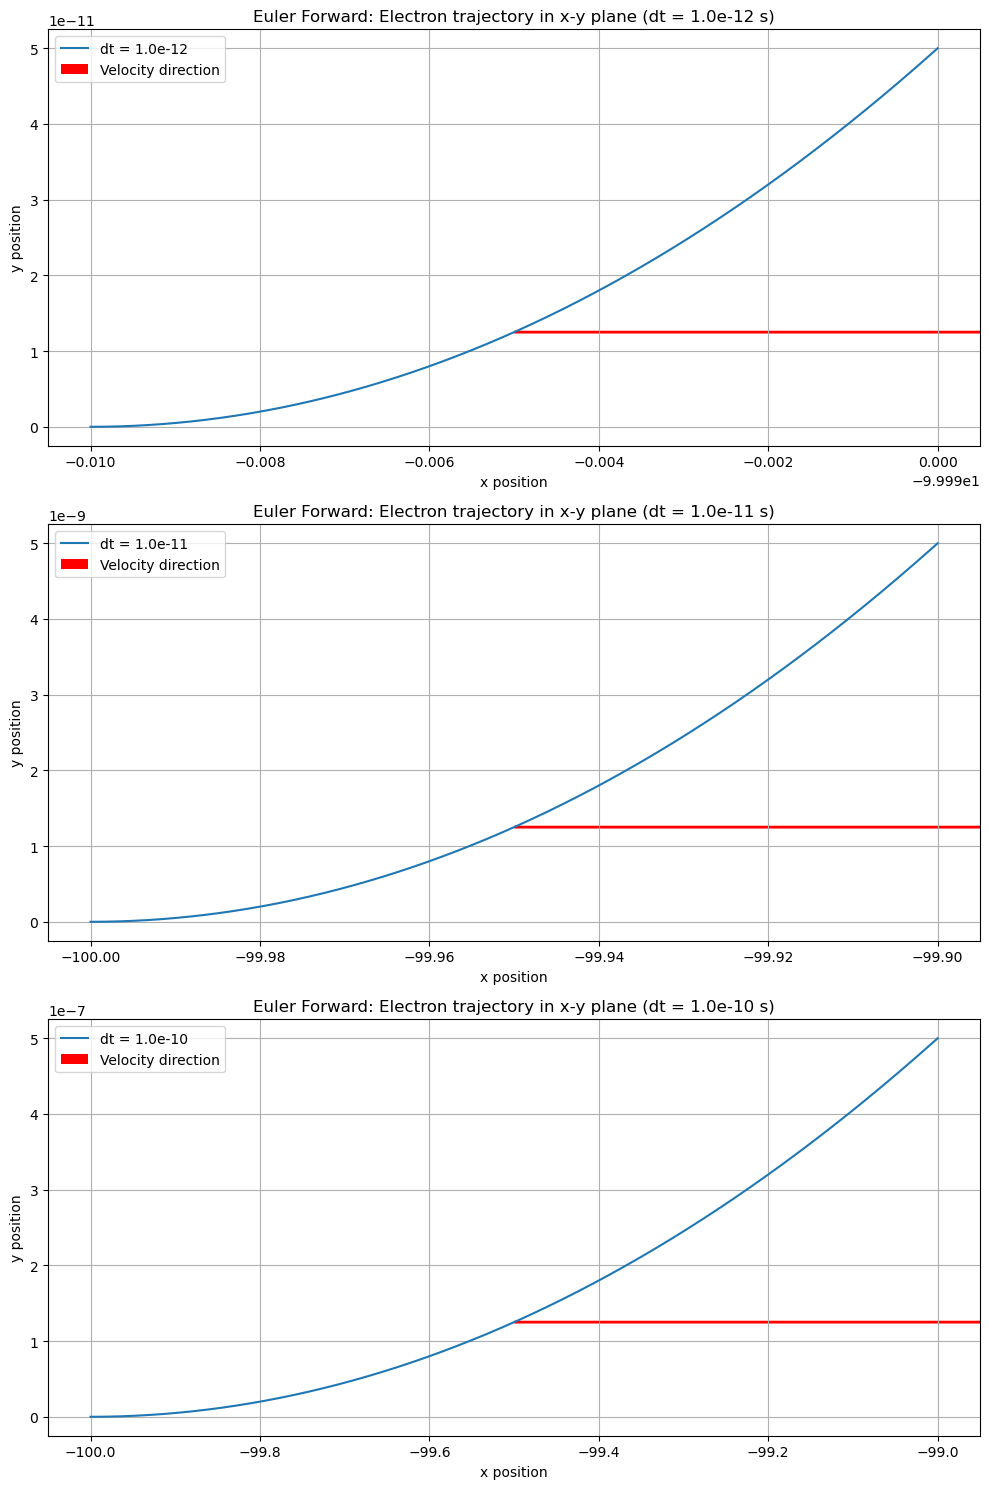

In [4]:
# Constants
q_electron = -1.0   # Normalised charge
m_electron = 1.0    # Normalised mass
n_steps = 10000
initial_velocity = np.array([1e6, 0, 0], dtype=float)
time_steps = [1e-12, 1e-11, 1e-10]
E_field = np.array([0, 0, 0], dtype=float)
B_field = np.array([0, 0, 1], dtype=float)

def initialize_particle():
    pos = np.array([-100, 0, 0], dtype=float)  # Starting position
    vel = initial_velocity.copy()
    return pos, vel

def lorentz_force(q, vel, E, B):
    return q * (E + np.cross(vel, B))

def euler_forward_integration(q, m, E, B, dt, n_steps):
    pos, vel = initialize_particle()
    positions, velocities = [], []
    for _ in range(n_steps):
        positions.append(pos.copy())
        velocities.append(vel.copy())
        acc = lorentz_force(q, vel, E, B) / m
        vel = vel + acc * dt
        pos = pos + vel * dt
    return np.array(positions), np.array(velocities)

fig, ax = plt.subplots(3, 1, figsize=(10, 15))
for idx, dt in enumerate(time_steps):
    positions, velocities = euler_forward_integration(q_electron, m_electron, E_field, B_field, dt, n_steps)
    ax[idx].plot(positions[:, 0], positions[:, 1], label=f"dt = {dt:.1e}")
    mid = n_steps // 2
    ax[idx].quiver(positions[mid, 0], positions[mid, 1],
                   velocities[mid, 0], velocities[mid, 1],
                   scale=1e-13, color='r', label="Velocity direction", width=0.003)
    ax[idx].set_title(f"Euler Forward: Electron trajectory in x-y plane (dt = {dt:.1e} s)")
    ax[idx].set_xlabel("x position")
    ax[idx].set_ylabel("y position")
    ax[idx].legend()
    ax[idx].grid(True)
plt.tight_layout()
plt.show()

# Observation: even at dt=1e-12 the gyroradius grows over time (spiral instead of circle),
# demonstrating that Euler's method does not conserve energy for magnetic fields.

## 2. Boris Method

The Boris method avoids Euler's instability by using the **average velocity** at the half-timestep $n+1/2$, decoupling the electric and magnetic steps.

**Step 1** — Half-kick from the electric field:
$$\mathbf{v}^- = \mathbf{v}^{n-1/2} + \frac{q}{m}\mathbf{E} \frac{\Delta t}{2}$$

**Step 2** — Magnetic rotation. Define:
$$\mathbf{t} = \frac{q\mathbf{B}}{m}\frac{\Delta t}{2}, \quad \mathbf{s} = \frac{2\mathbf{t}}{1 + |\mathbf{t}|^2}$$
$$\mathbf{v}' = \mathbf{v}^- + \mathbf{v}^- \times \mathbf{t}$$
$$\mathbf{v}^+ = \mathbf{v}^- + \mathbf{v}' \times \mathbf{s}$$

This is equivalent to the rotation equation:
$$\frac{\mathbf{v}^+ - \mathbf{v}^-}{\Delta t} = \frac{q}{2m}(\mathbf{v}^+ + \mathbf{v}^-) \times \mathbf{B}$$

**Step 3** — Second half-kick from the electric field:
$$\mathbf{v}^{n+1/2} = \mathbf{v}^+ + \frac{q}{m}\mathbf{E} \frac{\Delta t}{2}$$

Position is updated as: $\mathbf{r}^{n+1} = \mathbf{r}^n + \mathbf{v}^{n+1/2} \Delta t$

This leapfrog structure is time-reversible and energy-conserving for magnetic fields.

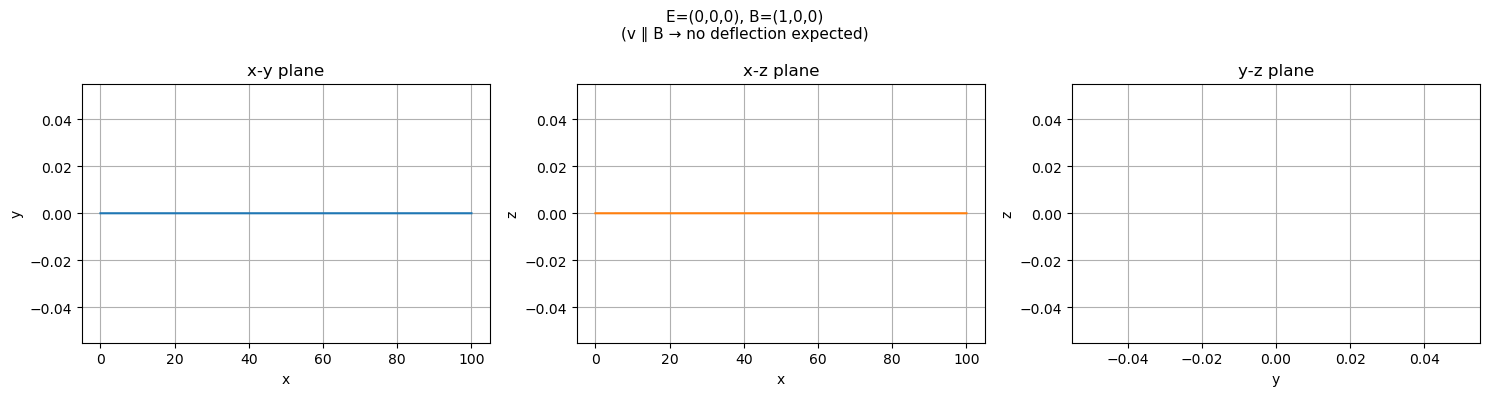

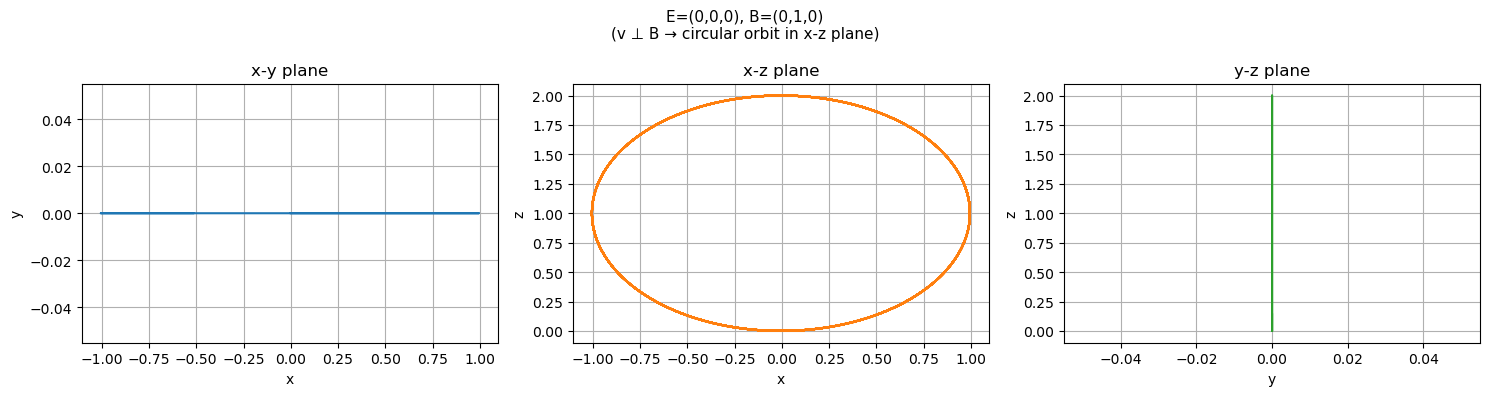

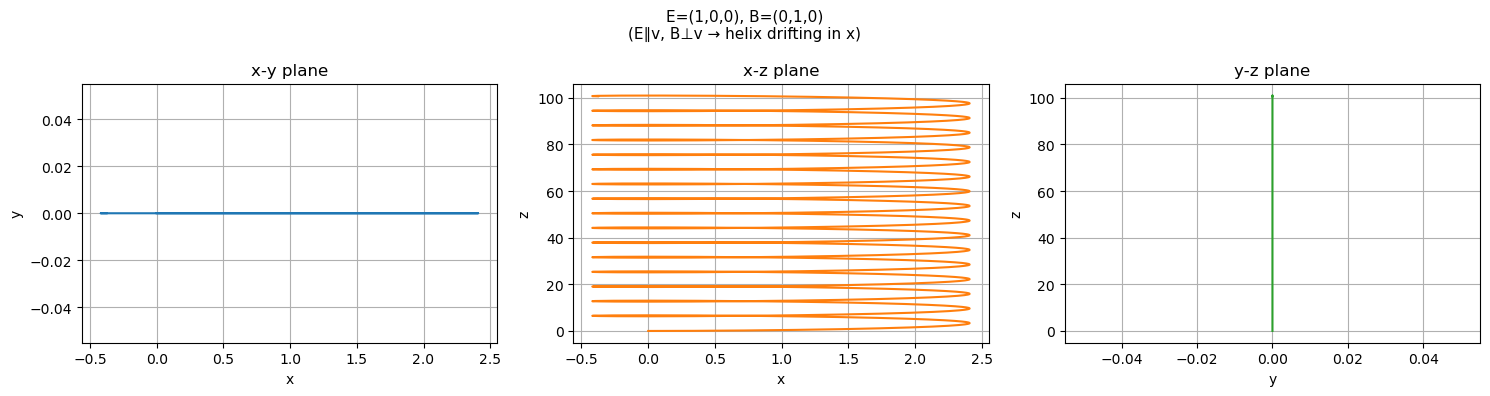

In [5]:
def boris(v, E, B, q, m, dt):
    """Boris particle pusher. E and B are NOT mutated."""
    v_minus = v + (q * E / m) * (dt / 2.0)
    t = (q * B / m) * (dt / 2.0)
    t_mag2 = np.dot(t, t)
    s = 2.0 * t / (1.0 + t_mag2)
    v_prime = v_minus + np.cross(v_minus, t)
    v_plus = v_minus + np.cross(v_prime, s)
    return v_plus + (q * E / m) * (dt / 2.0)


# Test: positive ion (q=m=1), v=(1,0,0) through various E/B configurations
q, m, dt, num_steps = 1.0, 1.0, 0.01, 10000
r_initial = np.array([0.0, 0.0, 0.0])
v_initial = np.array([1.0, 0.0, 0.0])

test_cases = [
    (np.array([0,0,0], dtype=float), np.array([1,0,0], dtype=float),
     "E=(0,0,0), B=(1,0,0)", "v ∥ B → no deflection expected"),
    (np.array([0,0,0], dtype=float), np.array([0,1,0], dtype=float),
     "E=(0,0,0), B=(0,1,0)", "v ⊥ B → circular orbit in x-z plane"),
    (np.array([1,0,0], dtype=float), np.array([0,1,0], dtype=float),
     "E=(1,0,0), B=(0,1,0)", "E∥v, B⊥v → helix drifting in x"),
]

for E_test, B_test, title, note in test_cases:
    r = r_initial.copy()
    v = v_initial.copy()
    trajectory = np.zeros((num_steps, 3))
    for i in range(num_steps):
        trajectory[i] = r
        v = boris(v, E_test, B_test, q, m, dt)
        r += v * dt

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{title}\n({note})", fontsize=11)
    planes = [((0,1),'x','y'), ((0,2),'x','z'), ((1,2),'y','z')]
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    for ax, (idx_pair, xl, yl), col in zip(axs, planes, colors):
        ax.plot(trajectory[:, idx_pair[0]], trajectory[:, idx_pair[1]], color=col)
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        ax.set_title(f"{xl}-{yl} plane")
        ax.grid(True)
    plt.tight_layout()
    plt.show()

## 3. Magnetic Bottle

A magnetic bottle consists of two opposing magnetic dipoles that create a region of weaker field between two stronger mirror points. Particles with a sufficiently large pitch angle (angle between velocity and field) are reflected and trapped.

Each dipole with moment $\boldsymbol{\mu}$ produces:
$$\mathbf{B}(\mathbf{r}) = \frac{\mu_0}{4\pi}\left(\frac{3\hat{r}(\boldsymbol{\mu}\cdot\hat{r})}{r^3} - \frac{\boldsymbol{\mu}}{r^3}\right)$$

The escape condition is set by the **loss cone angle**:
$$\sin^2\alpha_{min} = \frac{B_0}{B_{max}}$$
$$\alpha_{min} = \arcsin\sqrt{\frac{B_0}{B_{max}}}$$

Particles with pitch angle $\alpha > \alpha_{min}$ are trapped; those inside the loss cone escape.

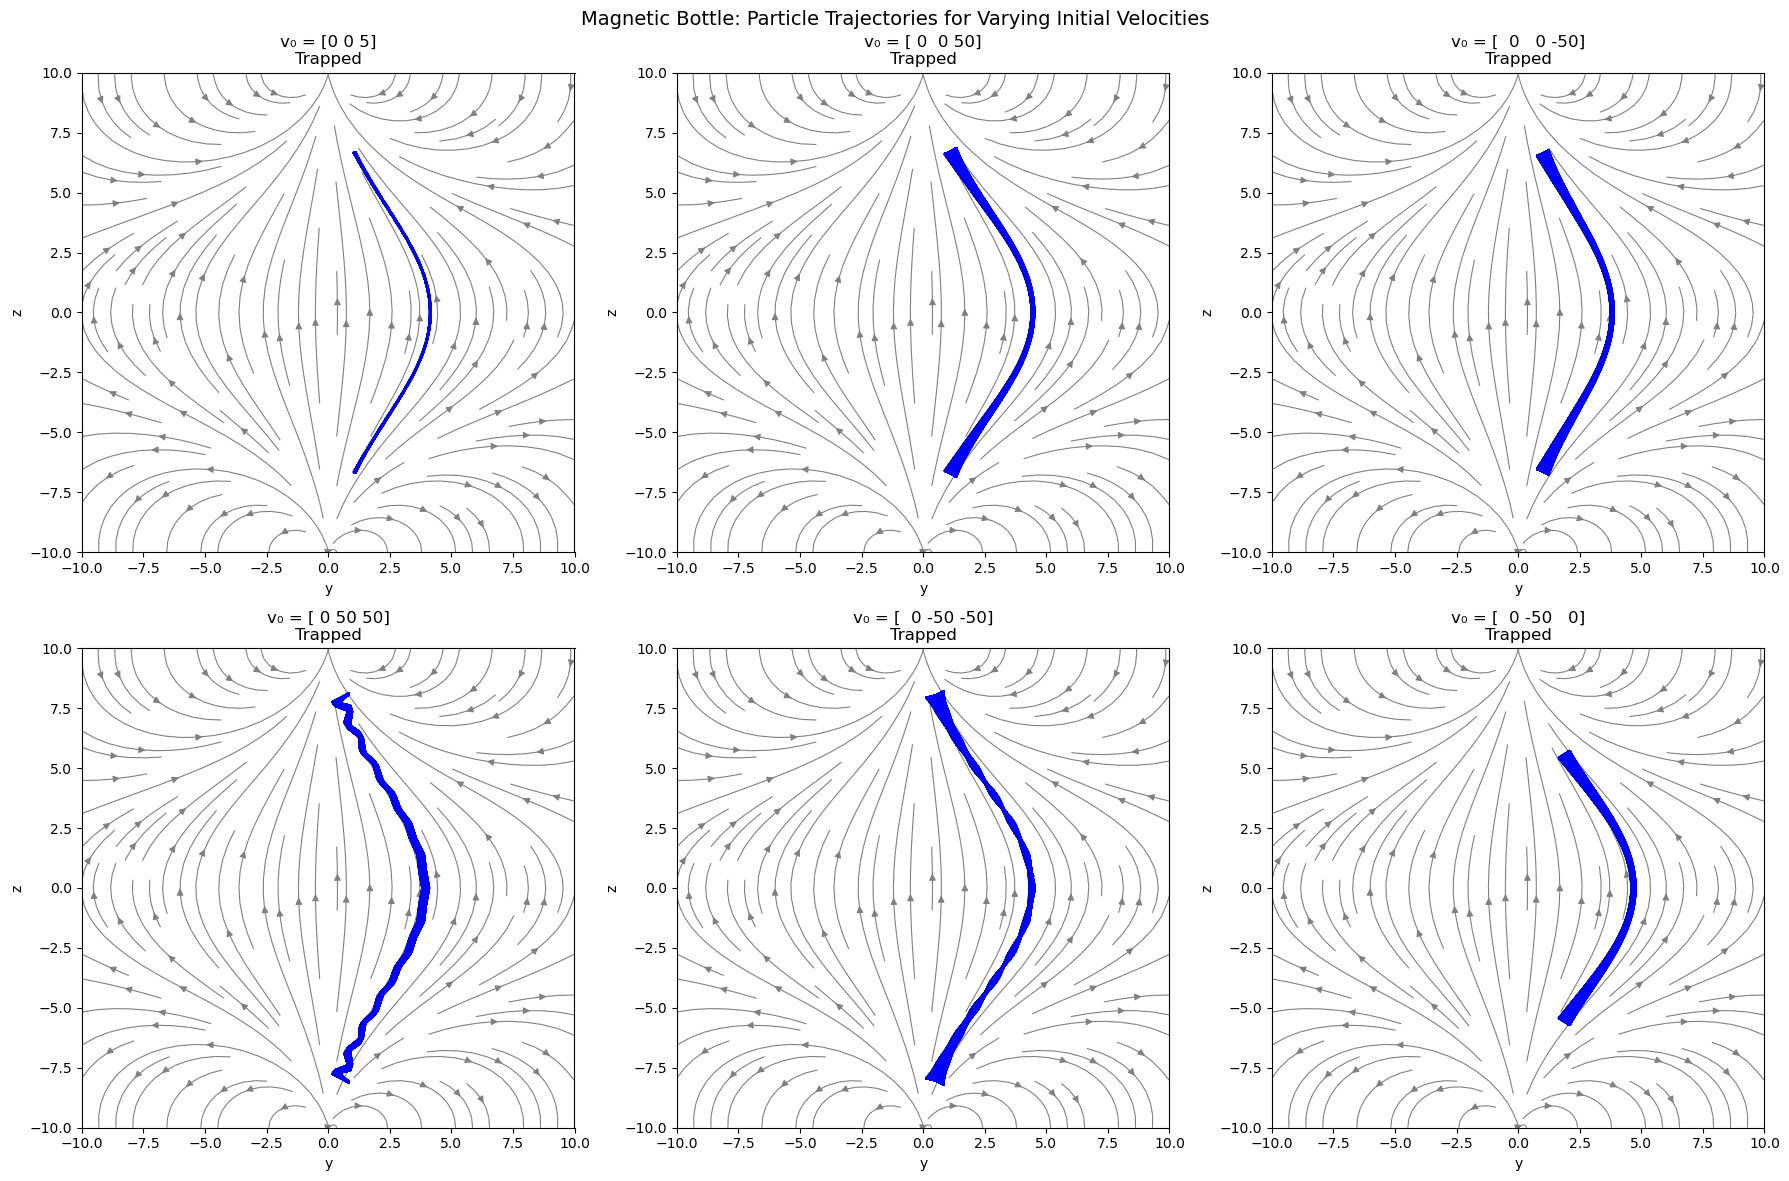

In [6]:
# --- Magnetic bottle field ---
mu0 = np.pi * 4.0e-7
mu = 10000.0 * np.array([0.0, 0.0, 1.0])  # Dipole moment in z-direction

def bottle(x, y, z, zdisp=10):
    """Total magnetic field from two opposing dipoles placed at ±zdisp."""
    posA = np.array([0.0, 0.0,  zdisp])
    rA   = np.array([x, y, z]) - posA
    rmagA = np.linalg.norm(rA)
    B_A  = (3.0 * rA * np.dot(mu, rA) / rmagA**5) - (mu / rmagA**3)

    posB = np.array([0.0, 0.0, -zdisp])
    rB   = np.array([x, y, z]) - posB
    rmagB = np.linalg.norm(rB)
    B_B  = (3.0 * rB * np.dot(mu, rB) / rmagB**5) - (mu / rmagB**3)

    return (mu0 / (4.0 * np.pi)) * (B_A + B_B)


# --- Precompute field grid for streamplot ---
y_grid = np.linspace(-10.0, 10.0, 200)
z_grid = np.linspace(-10.0, 10.0, 200)
Y, Z = np.meshgrid(y_grid, z_grid)
B_y = np.zeros_like(Y)
B_z = np.zeros_like(Z)
for i in range(Y.shape[0]):
    for j in range(Y.shape[1]):
        Bvec = bottle(0.0, Y[i,j], Z[i,j])
        B_y[i,j] = Bvec[1]
        B_z[i,j] = Bvec[2]


# --- Simulate 6 particles with different initial velocities ---
q_p, m_p = 1.0, 1.67e-27
dt_bottle, num_steps_bottle = 0.01, 2000
r0_bottle = np.array([0.0, 2.0, -5.0])

initial_velocities = [
    np.array([0,  0,   5]),   # slow, along z
    np.array([0,  0,  50]),   # fast, along z — should escape
    np.array([0,  0, -50]),   # fast, opposite z — should escape
    np.array([0, 50,  50]),   # diagonal
    np.array([0,-50, -50]),   # diagonal opposite
    np.array([0,-50,   0]),   # purely transverse — should be trapped
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, v_init in zip(axes.flatten(), initial_velocities):
    r = r0_bottle.copy()
    v = v_init.copy()
    trajectory = np.zeros((num_steps_bottle, 3))
    escaped_at = None
    for i in range(num_steps_bottle):
        trajectory[i] = r
        if np.linalg.norm(r) > 9.99:
            escaped_at = i
            trajectory = trajectory[:i+1]
            break
        B_local = bottle(r[0], r[1], r[2])
        v = boris(v, np.zeros(3), B_local, q_p, m_p, dt_bottle)
        r += v * dt_bottle

    ax.streamplot(Y, Z, B_y, B_z, color='gray', linewidth=0.8, density=1)
    ax.plot(trajectory[:, 1], trajectory[:, 2], color='blue', linewidth=2)
    status = f"Escaped at step {escaped_at}" if escaped_at else "Trapped"
    ax.set_title(f"v₀ = {v_init}\n{status}")
    ax.set_xlabel("y"); ax.set_ylabel("z")

plt.suptitle("Magnetic Bottle: Particle Trajectories for Varying Initial Velocities", fontsize=14)
plt.tight_layout()
plt.show()

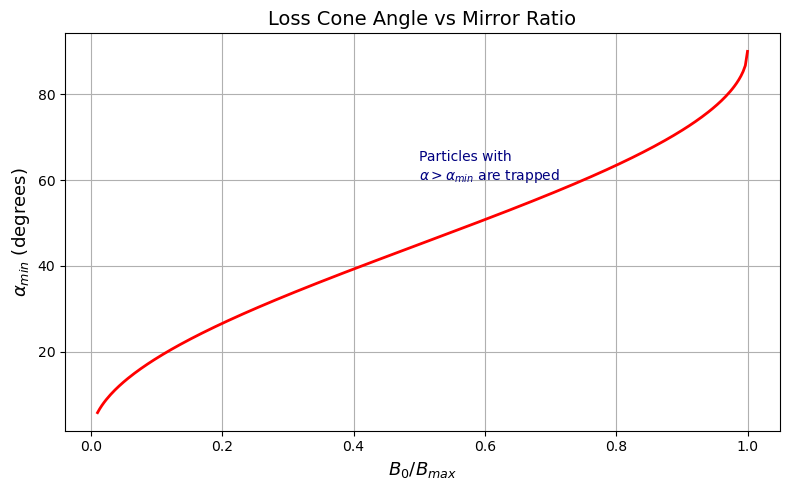

In [7]:
# --- Loss cone analysis ---
# The minimum pitch angle for trapping is: alpha_min = arcsin(sqrt(B0/Bmax))
# As B0/Bmax → 1 (mirror ratio → 1), the loss cone shrinks to 90°
# (only particles moving purely perpendicular are trapped).
# As B0/Bmax → 0 (strong mirrors), loss cone → 0° (almost all particles trapped).

B0_over_Bmax = np.linspace(0.01, 1.0, 300)
alpha_min_deg = np.degrees(np.arcsin(np.sqrt(B0_over_Bmax)))

plt.figure(figsize=(8, 5))
plt.plot(B0_over_Bmax, alpha_min_deg, color='red', linewidth=2)
plt.xlabel(r'$B_0 / B_{max}$', fontsize=13)
plt.ylabel(r'$\alpha_{min}$ (degrees)', fontsize=13)
plt.title('Loss Cone Angle vs Mirror Ratio', fontsize=14)
plt.grid(True)
plt.annotate('Particles with\n$\\alpha > \\alpha_{min}$ are trapped',
             xy=(0.5, 60), fontsize=10, color='navy')
plt.tight_layout()
plt.show()

## 4. Shear Flow at Mercury's Magnetopause

We model the boundary between Mercury's magnetosphere (MS) and the solar wind (SW). Two regions of opposite bulk velocity separated at $y=0$ induce a drift electric field:

$$\mathbf{E}_{drift} = \begin{cases} +v_0 \times B & y > 0 \\ -v_0 \times B & y \leq 0 \end{cases}$$

With $\mathbf{B} = (0, 0, B_z)$ and $\mathbf{v}_0 = (v_0, 0, 0)$, the cross product gives a drift field in the $y$-direction only:
$$E_y^{drift} = \mp v_0 B_z$$

The gyroradius and cyclotron frequency are:
$$r_g = \frac{mv_\perp}{|q|B}, \quad \omega_c = \frac{|q|B}{m}$$

Normalised units: r_g = 5.00, ω_c = 1.00


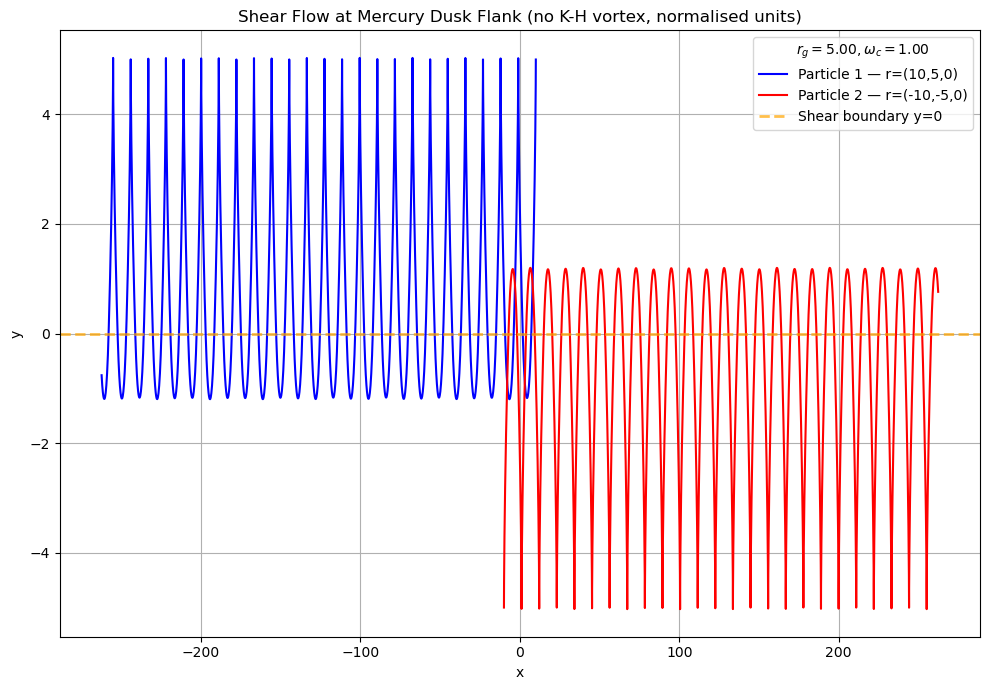

In [8]:
def drift_electric_field(r, v0_x, Bz):
    """Shear flow drift E-field. Returns a NEW array — does not mutate anything."""
    Ey = -v0_x * Bz if r[1] > 0 else v0_x * Bz
    return np.array([0.0, Ey, 0.0])


def boris_with_drift(v, r, B, v0_x, q, m, dt):
    """Boris step with shear-flow drift E-field computed from position."""
    E = drift_electric_field(r, v0_x, B[2])
    return boris(v, E, B, q, m, dt)


# --- Normalised units: q=m=1, B=1 ---
q_n, m_n = 1.0, 1.0
v0_n = np.array([5.0, 0.0, 0.0])
B_n  = np.array([0.0, 0.0, 1.0])
dt_n, nsteps_n = 0.01, 10000

rg_n = m_n * v0_n[0] / (q_n * B_n[2])
wc_n = q_n * B_n[2] / m_n
print(f"Normalised units: r_g = {rg_n:.2f}, ω_c = {wc_n:.2f}")

r1, r2 = np.array([10., 5., 0.]), np.array([-10., -5., 0.])
v1, v2 = np.zeros(3), np.zeros(3)
traj1 = np.zeros((nsteps_n, 3))
traj2 = np.zeros((nsteps_n, 3))

for i in range(nsteps_n):
    traj1[i] = r1;  v1 = boris_with_drift(v1, r1, B_n, v0_n[0], q_n, m_n, dt_n);  r1 += v1 * dt_n
    traj2[i] = r2;  v2 = boris_with_drift(v2, r2, B_n, v0_n[0], q_n, m_n, dt_n);  r2 += v2 * dt_n

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(traj1[:,0], traj1[:,1], color='blue',  label='Particle 1 — r=(10,5,0)')
ax.plot(traj2[:,0], traj2[:,1], color='red',   label='Particle 2 — r=(-10,-5,0)')
ax.axhline(0, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Shear boundary y=0')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Shear Flow at Mercury Dusk Flank (no K-H vortex, normalised units)')
rg_label = f"$r_g = {rg_n:.2f}, \\omega_c = {wc_n:.2f}$"
ax.legend(title=rg_label)
ax.grid(True)
plt.tight_layout()
plt.show()

Mercury proton: r_g = 24476.24 m, ω_c = 18.3852 rad/s


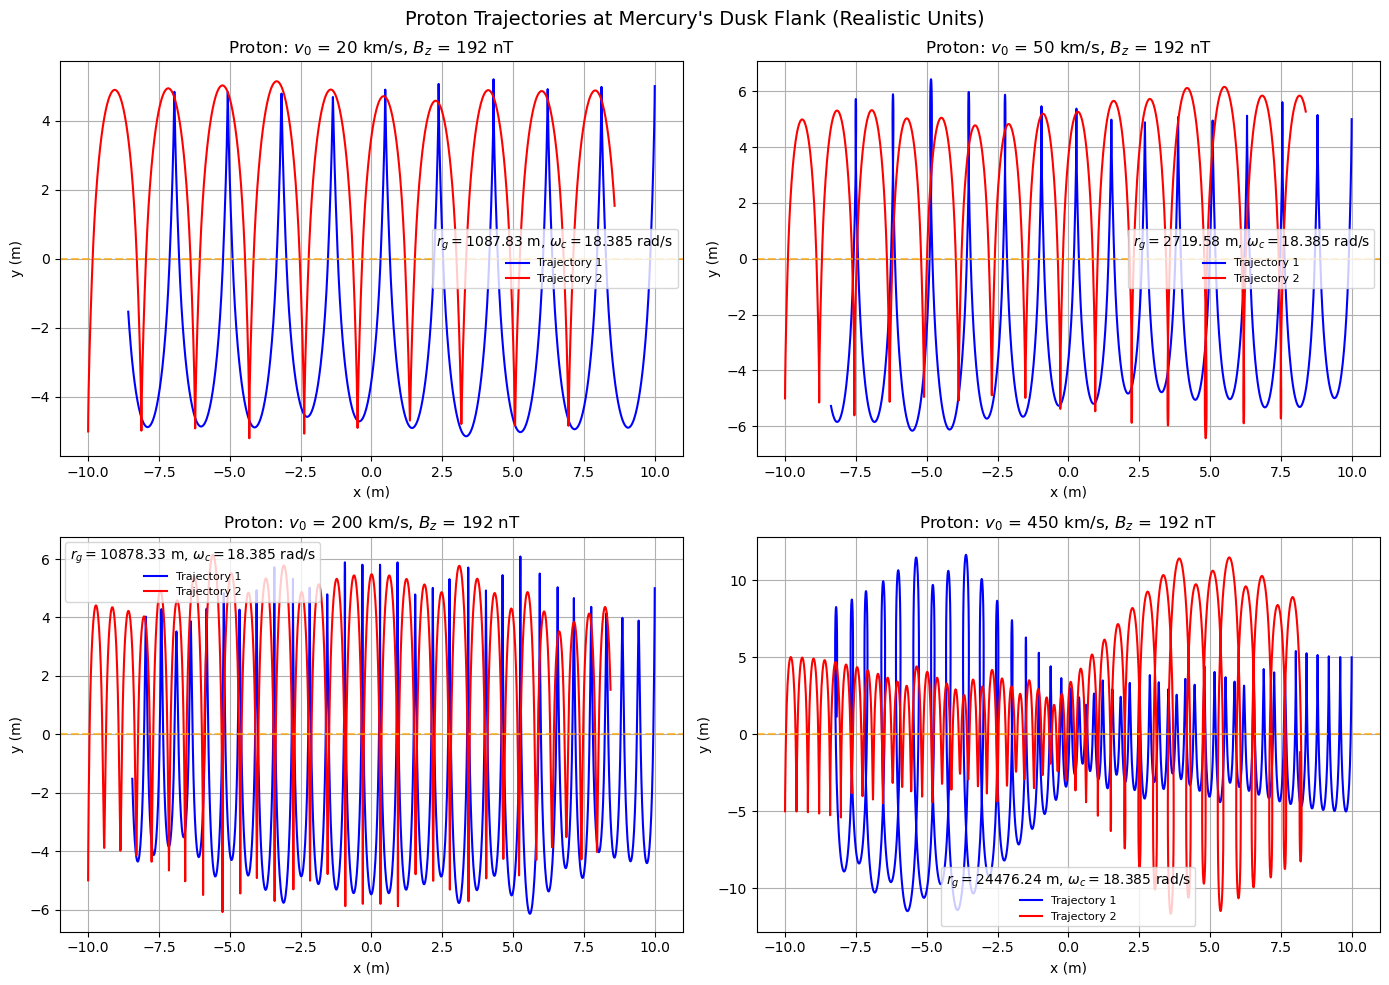

In [9]:
# --- Realistic units: proton near Mercury (B ≈ 192 nT, v_sw ≈ 450 km/s) ---
# Alexeev et al. (2008): B ~ 192 nT at Mercury's magnetopause
# Reiss et al. (2016):   solar wind speed ~ 407 ± 84 km/s

q_p  = 1.602e-19   # C
m_p  = 1.673e-27   # kg
Bz_merc = 192e-9   # T
v0_merc  = 450e3   # m/s

B_merc  = np.array([0.0, 0.0, Bz_merc])
v0_vec  = np.array([v0_merc, 0.0, 0.0])
dt_merc = 1e-4
nsteps_merc = 2000

rg_merc = m_p * v0_merc / (q_p * Bz_merc)
wc_merc = q_p * Bz_merc / m_p
print(f"Mercury proton: r_g = {rg_merc:.2f} m, ω_c = {wc_merc:.4f} rad/s")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
v0_sweep = [20e3, 50e3, 200e3, 450e3]

for ax, v0x in zip(axes.flatten(), v0_sweep):
    B_sw = np.array([0.0, 0.0, Bz_merc])
    r1s = np.array([10., 5., 0.])
    r2s = np.array([-10., -5., 0.])
    v1s, v2s = np.zeros(3), np.zeros(3)
    t1 = np.zeros((nsteps_merc, 3))
    t2 = np.zeros((nsteps_merc, 3))
    rg_s = m_p * v0x / (q_p * Bz_merc)
    wc_s = q_p * Bz_merc / m_p

    for i in range(nsteps_merc):
        t1[i] = r1s;  v1s = boris_with_drift(v1s, r1s, B_sw, v0x, q_p, m_p, dt_merc);  r1s += v1s * dt_merc
        t2[i] = r2s;  v2s = boris_with_drift(v2s, r2s, B_sw, v0x, q_p, m_p, dt_merc);  r2s += v2s * dt_merc

    ax.plot(t1[:,0], t1[:,1], color='blue', label='Trajectory 1')
    ax.plot(t2[:,0], t2[:,1], color='red',  label='Trajectory 2')
    ax.axhline(0, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_title(f"Proton: $v_0$ = {v0x/1e3:.0f} km/s, $B_z$ = 192 nT")
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    ax.legend(title=f"$r_g={rg_s:.2f}$ m, $\\omega_c={wc_s:.3f}$ rad/s", fontsize=8)
    ax.grid(True)

plt.suptitle("Proton Trajectories at Mercury's Dusk Flank (Realistic Units)", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Kelvin-Helmholtz Vortex

We now add a K-H vortex centred at the origin. The total electromagnetic field at position $(x, y)$ is (Gingell et al., 2014):

$$B_z = (-1)^m B_0$$
$$E_x = (-1)^{m+1} r^2 \exp(-r^2/R^2) \cos\theta$$
$$E_y = (-1)^{m+1} r^2 \exp(-r^2/R^2) \sin\theta + E_{drift}(y)$$

where $r^2 = x^2 + y^2$, $\theta = \arctan(y/x)$, and $R$ is the vortex radius.

- $m=1$: **corotating** vortex (dawn flank) — vorticity parallel to B
- $m=0$: **counterrotating** vortex (dusk flank) — vorticity antiparallel to B

K-H waves are observed almost exclusively at the **dusk flank** (counterrotating case).

In [ ]:
def kh_fields(r, R, m_mode, B0, v0_x):
    """
    Returns (E, B) for the K-H vortex setup.
    m_mode=0: counterrotating (dusk flank)
    m_mode=1: corotating     (dawn flank)
    """
    x, y = r[0], r[1]
    r_sq = x**2 + y**2
    theta = np.arctan2(y, x)
    sign = (-1)**(m_mode + 1)

    Ex = sign * r_sq * np.exp(-r_sq / R**2) * np.cos(theta) if R > 0 else 0.0
    Ey = sign * r_sq * np.exp(-r_sq / R**2) * np.sin(theta) if R > 0 else 0.0

    # Add drift field from shear flow
    Bz = (-1)**m_mode * B0
    Ey += -v0_x * Bz if y > 0 else v0_x * Bz

    E = np.array([Ex, Ey, 0.0])
    B = np.array([0.0, 0.0, Bz])
    return E, B


def run_kh_simulation(r_init, q, m, dt, num_steps, R, m_mode, B0, v0_x):
    """Run a single particle through the K-H vortex field."""
    r = r_init.copy()
    v = np.zeros(3)
    trajectory = np.zeros((num_steps, 3))
    for i in range(num_steps):
        trajectory[i] = r
        E, B = kh_fields(r, R, m_mode, B0, v0_x)
        v = boris(v, E, B, q, m, dt)
        r += v * dt
    return trajectory

In [ ]:
# --- 5.1 Charge polarity: counterrotating (dusk) vs corotating (dawn) ---
# Positive ion trapped by counterrotating vortex (dusk flank)
# Negative ion trapped by corotating vortex (dawn flank)

dt_kh, nsteps_kh = 0.005, 10000
B0_kh, v0_kh = 1.0, 1.0
R_values_charge = [0, 4, 5, 10]

for m_mode, mode_label in [(0, 'Counterrotating (dusk flank, m=0)'),
                            (1, 'Corotating (dawn flank, m=1)')]:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"Charge Polarity — {mode_label}", fontsize=13)

    for ax, R in zip(axes.flatten(), R_values_charge):
        r_start = np.array([10., 3., 0.])
        t_pos = run_kh_simulation(r_start, +1.0, 1.0, dt_kh, nsteps_kh, R, m_mode, B0_kh, v0_kh)
        t_neg = run_kh_simulation(r_start, -1.0, 1.0, dt_kh, nsteps_kh, R, m_mode, B0_kh, v0_kh)

        ax.plot(t_pos[:,0], t_pos[:,1], color='blue',  label='q=+1', linewidth=0.8)
        ax.plot(t_neg[:,0], t_neg[:,1], color='green', label='q=−1', linewidth=0.8)
        ax.axhline(0, color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='y=0')
        ax.set_title(f"R = {R}")
        ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.legend(fontsize=8)
        ax.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
# --- 5.2 Varying K-H vortex radius (counterrotating, two particles) ---
# Gyroradius = 1 in normalised units (q=m=v⊥=B=1)
# Key finding: effective trapping requires R > 2 * r_g

R_sweep = [0, 2, 3, 4, 5, 5.1, 5.5, 6, 8, 10, 15, 20]
n_cols = 3
n_rows = int(np.ceil(len(R_sweep) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
fig.suptitle("K-H Vortex Radius Sweep — Counterrotating (dusk flank)", fontsize=14)

for ax, R in zip(axes.flatten(), R_sweep):
    t1 = run_kh_simulation(np.array([10., 3., 0.]),  1.0, 1.0, 0.005, 10000, R, 0, 1.0, 1.0)
    t2 = run_kh_simulation(np.array([-10.,-3., 0.]), 1.0, 1.0, 0.005, 10000, R, 0, 1.0, 1.0)
    ax.plot(t1[:,0], t1[:,1], color='blue', linewidth=0.7, label='Particle 1')
    ax.plot(t2[:,0], t2[:,1], color='red',  linewidth=0.7, label='Particle 2')
    ax.axhline(0, color='orange', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(f"R = {R}")
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=7)
    ax.grid(True)

# Hide any unused axes
for ax in axes.flatten()[len(R_sweep):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# --- 5.3 Varying initial position (R=10, counterrotating) ---
# Conclusions:
# - Particles starting ON the vortex radius are tightly bound (symmetric petal orbits)
# - Particles within ~half the vortex radius are fully trapped
# - Particles further away are temporarily trapped then released

R_pos = 10
positions_on_radius = [
    np.array([ 0.,  10., 0.]),
    np.array([ 0., -10., 0.]),
    np.array([ 10.,  0., 0.]),
    np.array([-10.,  0., 0.]),
]
positions_close = [
    np.array([30., 0., 0.]),
    np.array([30., 1., 0.]),
    np.array([30., 5., 0.]),
]
positions_far = [
    np.array([30., 10., 0.]),
    np.array([30., 20., 0.]),
    np.array([30., 50., 0.]),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
titles = ['On vortex radius', 'Close to vortex (rx=30, ry=0–5)', 'Far from vortex (rx=30, ry=10–50)']
position_sets = [positions_on_radius, positions_close, positions_far]
palette = ['blue', 'green', 'purple', 'orange']

for ax, pos_set, title in zip(axes, position_sets, titles):
    for pos, col in zip(pos_set, palette):
        t = run_kh_simulation(pos, 1.0, 1.0, 0.01, 10000, R_pos, 0, 1.0, 1.0)
        ax.plot(t[0,0], t[0,1], 'x', color=col, markersize=10)
        ax.plot(t[:,0], t[:,1], color=col, linewidth=0.8,
                label=f"r=({pos[0]:.0f},{pos[1]:.0f})")
    circle = plt.Circle((0, 0), R_pos, color='black', fill=False, linestyle='-', linewidth=2)
    ax.add_artist(circle)
    ax.axhline(0, color='orange', linestyle='--', linewidth=1.2, alpha=0.5)
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8); ax.grid(True)

plt.suptitle("Effect of Initial Position on K-H Vortex Trapping (R=10)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# --- 5.4 Realistic particles near Mercury (R=500, B=192nT, v_sw=450km/s) ---
# Tests: electron, Na⁺, proton, antiproton
# Na⁺ gyration may seed K-H instability at the dusk boundary (Gingell et al., 2014)

B0_real  = 192e-9   # T
v0_real  = 450e3    # m/s
R_real   = 500      # normalised vortex radius scaled to realistic gyroradii
dt_real  = 0.05
nsteps_real = 200

particles = [
    {"label": "Electron (e⁻)",    "q": -1.602e-19, "m": 9.109e-31},
    {"label": "Sodium Ion (Na⁺)", "q":  1.602e-19, "m": 3.818e-26},
    {"label": "Proton (p)",        "q":  1.602e-19, "m": 1.673e-27},
    {"label": "Antiproton (p̄)",   "q": -1.602e-19, "m": 1.673e-27},
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, p in zip(axes.flatten(), particles):
    rg_p = p["m"] * v0_real / (abs(p["q"]) * B0_real)
    wc_p = abs(p["q"]) * B0_real / p["m"]
    r_start = np.array([15., 10., 0.])

    # No vortex first (drift only)
    t_drift = run_kh_simulation(r_start, p["q"], p["m"], dt_real, nsteps_real,
                                 0, 0, B0_real, v0_real)
    ax.plot(t_drift[:,0], t_drift[:,1], color='gray', linewidth=0.8,
            linestyle='--', label='Drift only')

    # With vortex
    t_vortex = run_kh_simulation(r_start, p["q"], p["m"], dt_real, nsteps_real,
                                  R_real, 0, B0_real, v0_real)
    ax.plot(t_vortex[:,0], t_vortex[:,1], color='mediumslateblue', linewidth=1.2,
            label=f'With vortex R={R_real}')

    ax.axhline(0, color='orange', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_title(p["label"])
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8,
              title=f"$r_g={rg_p:.2e}$ m\n$\\omega_c={wc_p:.2e}$ rad/s",
              title_fontsize=8)
    ax.grid(True)

plt.suptitle("Realistic Particles at Mercury's Magnetopause (B=192nT, v_sw=450km/s)", fontsize=13)
plt.tight_layout()
plt.show()

## Summary of Key Results

| Finding | Detail |
|---|---|
| Euler instability | Gyroradius grows unboundedly even at $\Delta t = 10^{-12}$ s |
| Boris method | Energy-conserving; accurate for all tested E/B configurations |
| Magnetic bottle | Trapping governed by loss cone: $\alpha_{min} = \arcsin\sqrt{B_0/B_{max}}$ |
| K-H charge asymmetry | Positive ions trapped by counterrotating (dusk); negative by corotating (dawn) |
| K-H radius threshold | Effective trapping requires $R > 2\, r_g$ |
| K-H initial position | Full trapping only if initial position within $\sim R/2$ of vortex centre |
| Realistic particles | Na⁺ forms near-circular orbits; electrons erratic; protons form petal orbits |